## Digit Recognizer Using MNIST Dataset

##### Libraries and modules to be imported below

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets 
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform = transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)



In [3]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [4]:
iterator = iter(train_loader)
image, label = next(iterator)
print("First batch of image: ", image.shape, label.shape)

First batch of image:  torch.Size([128, 1, 28, 28]) torch.Size([128])


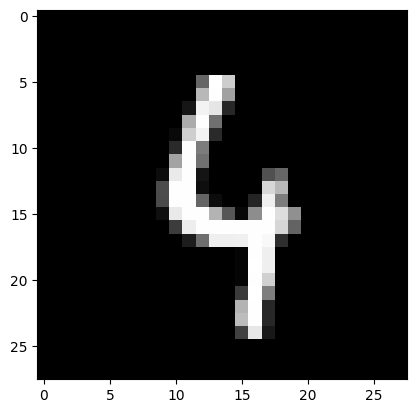

In [5]:
plt.imshow(image[0].squeeze(), cmap="gray")
plt.show()

In [6]:
print(image[0], label[0])

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [7]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Linear(28*28, 256)
        self.second = nn.Linear(256, 128)
        self.third = nn.Linear(128, 64)
        self.fourth = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.relu(self.first(x))
        x = self.dropout(x)
        x = self.relu(self.second(x))
        x = self.dropout(x)
        x = self.relu(self.third(x))
        x = self.dropout(x)
        x = self.fourth(x)

        return x

model = Classifier()
print(model)

Classifier(
  (first): Linear(in_features=784, out_features=256, bias=True)
  (second): Linear(in_features=256, out_features=128, bias=True)
  (third): Linear(in_features=128, out_features=64, bias=True)
  (fourth): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
)


In [8]:
def calc_loss(logits, targets):
    probs = F.softmax(logits, dim=1)
    batch_size = logits.size(0)
    true_probs = probs[range(batch_size), targets]

    log_probs = -torch.log(true_probs)
    loss = log_probs.mean()
    return loss

In [9]:
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [10]:
def training(epochs):

    for e in range(epochs):

        running_loss = 0

        for images, labels in train_loader:

            optimizer.zero_grad()

            logits = model(images)

            loss = calc_loss(logits, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch: {e+1} - Training loss: {running_loss/len(train_loader):.4f}")


In [11]:
training(5)

Epoch: 1 - Training loss: 0.4310
Epoch: 2 - Training loss: 0.1540
Epoch: 3 - Training loss: 0.1068
Epoch: 4 - Training loss: 0.0831
Epoch: 5 - Training loss: 0.0685


In [15]:
def testing():
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            logits = model(images)

            predictions = torch.argmax(logits, dim = 1)

            correct += (predictions==labels).sum().item()

            total+= labels.size(0)

    accuracy = (correct/total) * 100
    print(f"Test Accuracy: {accuracy:.2f}%")

In [16]:
testing()

Test Accuracy: 97.48%


In [18]:
torch.save(model.state_dict(), 'digit_recognizer_model.pth')
print("Model saved successfully")

Model saved successfully
